<a href="https://colab.research.google.com/github/blakejones-1/Bradford_Jones_Pref_Performance/blob/main/Bradford_Jones_Pref_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Analytical path as laid out in the pre-analysis plan
##1. Correlation analysis: Compute Spearman and Kendall-τ correlations between PI and TI, including bootstrap confidence intervals
##2. Hierarchical regression: Task index = α + β1P Ii + β2Reasoningi + β3TrainStylei + β4 log(Paramsi) + uModelFam[i] + ϵi
##3. Nonlinearity and Thresholds: Fit spline and piecewise regressions to detect saturation effects (diminishing returns from preference alignment).
##4. Bayesian Model Comparison: Estimate posterior distributions over β coefficients and use WAIC to compare linear vs. nonlinear formulations.
##5. Causal Sensitivity: Perform partial correlation and conditional independence tests (controlling for model size and release date) to assess whether preference alignment causally mediates performance improvements.

In [ ]:
from google.colab import files

#Load data
uploaded = files.upload()

Saving Frontier_Model_Outcomes_v1600.csv to Frontier_Model_Outcomes_v1600.csv


ChatbotArena_Elo vs ARC-AGI-2
Spearman correlation: 0.872, p-value: 0.054
Kendall tau:          0.738, p-value: 0.077


/tmp/ipython-input-4109078294.py:68: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = stats.spearmanr(x[idx], y[idx])


Spearman 95% CI: (np.float64(nan), np.float64(nan))
Kendall tau 95% CI: (np.float64(nan), np.float64(nan))


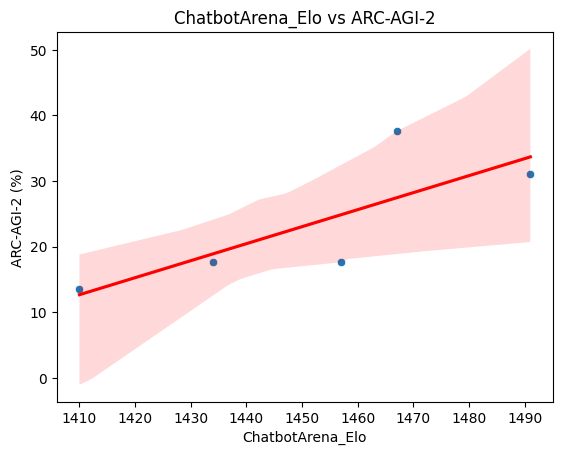

In [ ]:
#1: Computing Spearman and Kendall-t correlations
# Import libraries
import pandas as pd
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load data
# -----------------------------
df = pd.read_csv("Frontier_Model_Outcomes_v1600.csv")

# Clean up columns:
# - ChatbotArena_Elo should be numeric
# - Benchmark columns are percentages as strings like "91.90%", so strip "%" and convert to float

df["ChatbotArena_Elo"] = pd.to_numeric(df["ChatbotArena_Elo"], errors="coerce")

percent_cols = ["AIME (no tools)", "GPQA Diamond", "ARC-AGI-2", "MMLU", "SWE_Bench"]
for col in percent_cols:
    df[col] = (
        df[col]
        .astype(str)          # in case of NaN
        .str.rstrip("%")      # remove trailing %
        .replace("nan", np.nan)
        .astype(float)
    )

# -----------------------------
# 2. Choose PI and TI columns
# -----------------------------
# Treat Elo as Preference Index (PI)
# Pick one capability metric as Task Index (TI), e.g. ARC-AGI-2
# You can change "ARC-AGI-2" to "MMLU", "GPQA Diamond", etc.

PI_col = "ChatbotArena_Elo"
TI_col = "ARC-AGI-2"

x = df[PI_col].values
y = df[TI_col].values

# Drop pairs where either value is NaN
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# -----------------------------
# 3. Compute correlations
# -----------------------------
spearman_corr, spearman_p = stats.spearmanr(x, y)
kendall_corr, kendall_p = stats.kendalltau(x, y)

print(f"{PI_col} vs {TI_col}")
print(f"Spearman correlation: {spearman_corr:.3f}, p-value: {spearman_p:.3f}")
print(f"Kendall tau:          {kendall_corr:.3f}, p-value: {kendall_p:.3f}")

# -----------------------------
# 4. Bootstrap confidence intervals
# -----------------------------
def bootstrap_corr(x, y, method='spearman', n_iter=1000, seed=42):
    np.random.seed(seed)
    n = len(x)
    boot_corrs = []
    for _ in range(n_iter):
        idx = np.random.choice(n, n, replace=True)
        if method == 'spearman':
            corr, _ = stats.spearmanr(x[idx], y[idx])
        elif method == 'kendall':
            corr, _ = stats.kendalltau(x[idx], y[idx])
        boot_corrs.append(corr)
    lower = np.percentile(boot_corrs, 2.5)
    upper = np.percentile(boot_corrs, 97.5)
    return lower, upper

spearman_ci = bootstrap_corr(x, y, method='spearman')
kendall_ci = bootstrap_corr(x, y, method='kendall')

print(f"Spearman 95% CI: {spearman_ci}")
print(f"Kendall tau 95% CI: {kendall_ci}")

# -----------------------------
# 5. Scatterplot with regression line
# -----------------------------
sns.scatterplot(x=x, y=y)
sns.regplot(x=x, y=y, scatter=False, color='red')
plt.title(f"{PI_col} vs {TI_col}")
plt.xlabel(PI_col)
plt.ylabel(f"{TI_col} (%)")
plt.show()


In [ ]:
metrics = ["AIME (no tools)", "GPQA Diamond", "ARC-AGI-2", "MMLU", "SWE_Bench"]

for metric in metrics:
    x = df["ChatbotArena_Elo"].values
    y = df[metric].values
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_m = x[mask]
    y_m = y[mask]

    spearman_corr, spearman_p = stats.spearmanr(x_m, y_m)
    kendall_corr, kendall_p = stats.kendalltau(x_m, y_m)

    print(f"\nChatbotArena_Elo vs {metric}")
    print(f"  Spearman: {spearman_corr:.3f} (p={spearman_p:.3f})")
    print(f"  Kendall:  {kendall_corr:.3f} (p={kendall_p:.3f})")



ChatbotArena_Elo vs AIME (no tools)
  Spearman: 0.632 (p=0.368)
  Kendall:  0.548 (p=0.279)

ChatbotArena_Elo vs GPQA Diamond
  Spearman: 0.667 (p=0.219)
  Kendall:  0.527 (p=0.207)

ChatbotArena_Elo vs ARC-AGI-2
  Spearman: 0.872 (p=0.054)
  Kendall:  0.738 (p=0.077)

ChatbotArena_Elo vs MMLU
  Spearman: 0.667 (p=0.219)
  Kendall:  0.527 (p=0.207)

ChatbotArena_Elo vs SWE_Bench
  Spearman: -0.359 (p=0.553)
  Kendall:  -0.316 (p=0.448)


In [ ]:
#2. Hierarchical regression not possible given insufficient data

Rows used in regression: 5
                            Model    TI      PI_z
0                    Gemini 3 Pro  31.1  1.262089
1               Claude Sonnet 4.5  13.6 -1.345799
2  Claude Opus 4.5 (thinking-32k)  37.6  0.489381
3                  GPT-5.1 (high)  17.6  0.167420
4                         GPT-5.1  17.6 -0.573091

Using df_spline=3 with n=5 (≥1 residual df).

=== Spline regression results ===
                            OLS Regression Results                            
Dep. Variable:                     TI   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                 -0.216
Method:                 Least Squares   F-statistic:                    0.7629
Date:                Sat, 06 Dec 2025   Prob (F-statistic):              0.665
Time:                        04:10:30   Log-Likelihood:                -15.220
No. Observations:                   5   AIC:                             38.44
Df Residuals:                       1  

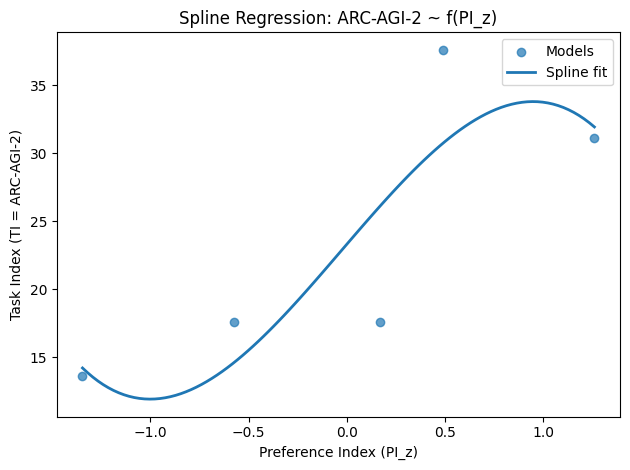


=== Best piecewise model ===
Best knot (PI_z): 0.644
AIC: 37.15
                            OLS Regression Results                            
Dep. Variable:                     TI   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     1.857
Date:                Sat, 06 Dec 2025   Prob (F-statistic):              0.350
Time:                        04:10:31   Log-Likelihood:                -15.573
No. Observations:                   5   AIC:                             37.15
Df Residuals:                       2   BIC:                             35.97
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

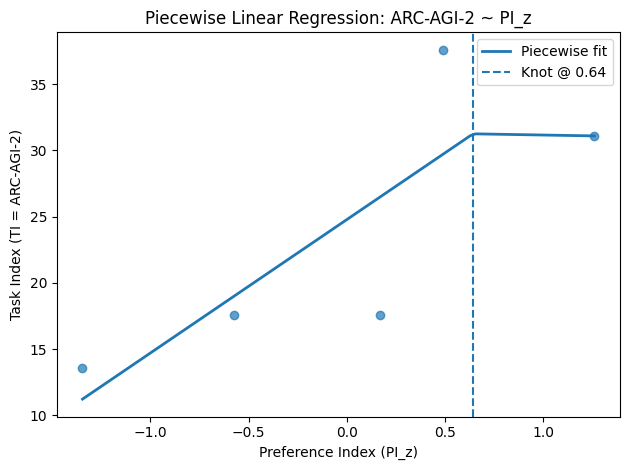


Bootstrap piecewise: successful fits = 1997 / 2000

Bootstrap 95% CIs (piecewise):
Knot: -1.346 → 1.262
Slope before: -8.222 → 62.119
Slope after: -84.762 → 103.532

Bootstrap means:
knot             0.242014
slope_before     8.848412
slope_after     16.710496
dtype: float64

Bootstrap spline fits: 1996


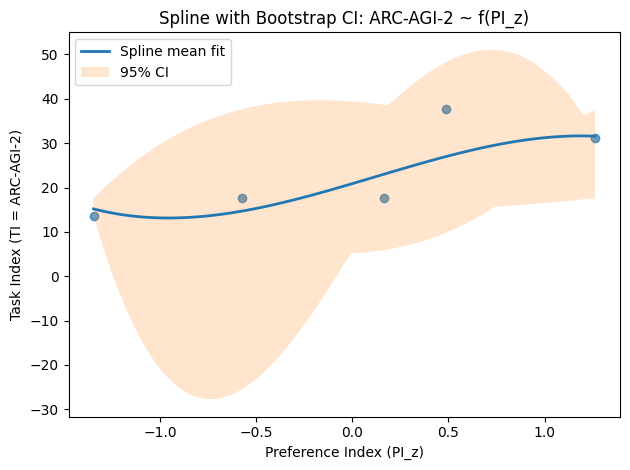

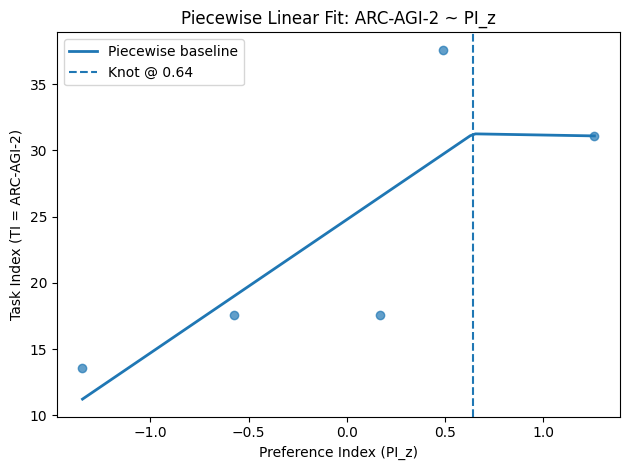

In [ ]:
# 3. Nonlinearity and Thresholds:
#    Fit spline and piecewise regressions to detect saturation effects
#    (Elo -> Task Index)
# -------------------------------------------------
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix
import matplotlib.pyplot as plt
import warnings

# Optional: silence normality and log(0) warnings that are expected with tiny n and bootstraps
warnings.filterwarnings(
    "ignore",
    message="omni_normtest is not valid with less than 8 observations"
)
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message="divide by zero encountered in log"
)


# Optional: silence normality warnings (irrelevant with tiny n)
warnings.filterwarnings(
    "ignore",
    message="omni_normtest is not valid with less than 8 observations"
)

# Rename the model-name column for convenience
df = df.rename(columns={"Unnamed: 0": "Model"})

# Rough model family from first token of model name (for inspection if needed)
df["ModelFam"] = df["Model"].str.split().str[0]

# Convert Elo to numeric
df["ChatbotArena_Elo"] = pd.to_numeric(df["ChatbotArena_Elo"], errors="coerce")

# Convert percentage metrics to float (e.g. "37.6%" → 37.6)
percent_cols = ["AIME (no tools)", "GPQA Diamond", "ARC-AGI-2", "MMLU", "SWE_Bench"]
for col in percent_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.rstrip("%")
        .replace("nan", np.nan)
        .astype(float)
    )

# Choose which benchmark is the Task Index (TI)
TI_col = "ARC-AGI-2"

df["TI"] = df[TI_col]
df["PI"] = df["ChatbotArena_Elo"]

# Standardize PI for interpretability
df["PI_z"] = (df["PI"] - df["PI"].mean()) / df["PI"].std()

# Keep only rows with both TI and PI_z present
df_reg = df.dropna(subset=["TI", "PI_z"]).copy()

print("Rows used in regression:", len(df_reg))
print(df_reg[["Model", "TI", "PI_z"]])

# ===================================================================
# A. Spline regression: TI ~ f(PI_z)
# ===================================================================

n = len(df_reg)

# Adaptive spline degrees:
# require df_resid >= 1  → df_spline ≤ n - 2
max_df_allowed = max(1, n - 2)
df_spline = min(4, max_df_allowed)

if df_spline < 2:
    print(f"\n[WARN] Only {n} points — spline nearly linear (df={df_spline}).")
else:
    print(f"\nUsing df_spline={df_spline} with n={n} (≥1 residual df).")

# Build spline basis
spline_basis = dmatrix(
    f"bs(PI_z, df={df_spline}, degree=3, include_intercept=False)",
    data=df_reg,
    return_type="dataframe",
)

# Design matrix — dmatrix includes intercept already
X_spline = spline_basis
y = df_reg["TI"]

# Fit spline model
spline_model = sm.OLS(y, X_spline).fit()
print("\n=== Spline regression results ===")
print(spline_model.summary())

# Predict spline on grid
pi_grid = np.linspace(df_reg["PI_z"].min(), df_reg["PI_z"].max(), 100)

spline_grid = dmatrix(
    f"bs(x, df={df_spline}, degree=3, include_intercept=False)",
    {"x": pi_grid},
    return_type="dataframe",
)
y_hat_spline = spline_model.predict(spline_grid)

# Plot spline fit
plt.figure()
plt.scatter(df_reg["PI_z"], df_reg["TI"], alpha=0.7, label="Models")
plt.plot(pi_grid, y_hat_spline, linewidth=2, label="Spline fit")
plt.xlabel("Preference Index (PI_z)")
plt.ylabel(f"Task Index (TI = {TI_col})")
plt.title(f"Spline Regression: {TI_col} ~ f(PI_z)")
plt.legend()
plt.tight_layout()
plt.show()

# ===================================================================
# B. Piecewise regression: TI ~ PI_z + hinge(PI_z - knot)
# ===================================================================

def fit_piecewise(knot, data):
    df_local = data.copy()
    df_local["hinge"] = np.clip(df_local["PI_z"] - knot, 0, None)
    return smf.ols("TI ~ PI_z + hinge", data=df_local).fit()

candidate_knots = np.percentile(df_reg["PI_z"], [20, 30, 40, 50, 60, 70, 80])

best_knot = None
best_model = None
best_aic = np.inf

for k in candidate_knots:
    m = fit_piecewise(k, df_reg)
    if m.aic < best_aic:
        best_aic = m.aic
        best_knot = k
        best_model = m

print("\n=== Best piecewise model ===")
print(f"Best knot (PI_z): {best_knot:.3f}")
print(f"AIC: {best_aic:.2f}")
print(best_model.summary())

print("\nPiecewise slopes:")
beta_pi = best_model.params["PI_z"]
beta_hinge = best_model.params["hinge"]
print(f"Slope before knot: {beta_pi:.4f}")
print(f"Slope after knot:  {beta_pi + beta_hinge:.4f}")

# Plot piecewise fit
pi_grid = np.linspace(df_reg["PI_z"].min(), df_reg["PI_z"].max(), 100)
hinge_grid = np.clip(pi_grid - best_knot, 0, None)

pred_df = pd.DataFrame({"PI_z": pi_grid, "hinge": hinge_grid})
y_hat_piecewise = best_model.predict(pred_df)

plt.figure()
plt.scatter(df_reg["PI_z"], df_reg["TI"], alpha=0.7)
plt.plot(pi_grid, y_hat_piecewise, linewidth=2, label="Piecewise fit")
plt.axvline(best_knot, linestyle="--", label=f"Knot @ {best_knot:.2f}")
plt.xlabel("Preference Index (PI_z)")
plt.ylabel(f"Task Index (TI = {TI_col})")
plt.title(f"Piecewise Linear Regression: {TI_col} ~ PI_z")
plt.legend()
plt.tight_layout()
plt.show()

# ===================================================================
# Bootstrap piecewise: knot + slopes
# ===================================================================

n_boot = 2000
boot_rows = []
rng = np.random.default_rng(42)

for b in range(n_boot):
    idx = rng.choice(n, n, replace=True)
    sample = df_reg.iloc[idx].copy()

    # must vary PI_z
    if sample["PI_z"].nunique() < 2:
        continue

    try:
        candidate_knots_b = np.percentile(sample["PI_z"], [20, 30, 40, 50, 60, 70, 80])
        best_knot_b = None
        best_model_b = None
        best_aic_b = np.inf

        for k in candidate_knots_b:
            m_b = fit_piecewise(k, sample)
            if m_b.aic < best_aic_b:
                best_aic_b = m_b.aic
                best_knot_b = k
                best_model_b = m_b

        boot_rows.append({
            "knot": best_knot_b,
            "slope_before": best_model_b.params["PI_z"],
            "slope_after": best_model_b.params["PI_z"] + best_model_b.params["hinge"],
        })

    except:
        continue

boot_df = pd.DataFrame(boot_rows)

print(f"\nBootstrap piecewise: successful fits = {len(boot_df)} / {n_boot}")

alpha = 0.05
ci_piecewise = boot_df.quantile([alpha/2, 1 - alpha/2])

print("\nBootstrap 95% CIs (piecewise):")
print(f"Knot: {ci_piecewise.loc[alpha/2, 'knot']:.3f} → {ci_piecewise.loc[1-alpha/2, 'knot']:.3f}")
print(f"Slope before: {ci_piecewise.loc[alpha/2, 'slope_before']:.3f} → {ci_piecewise.loc[1-alpha/2, 'slope_before']:.3f}")
print(f"Slope after: {ci_piecewise.loc[alpha/2, 'slope_after']:.3f} → {ci_piecewise.loc[1-alpha/2, 'slope_after']:.3f}")

print("\nBootstrap means:")
print(boot_df.mean())

# ===================================================================
# Bootstrap spline band
# ===================================================================

n_boot_spline = 2000
spline_preds = []

for b in range(n_boot_spline):
    idx = rng.choice(n, n, replace=True)
    sample = df_reg.iloc[idx].copy()

    if sample["PI_z"].nunique() < 2:
        continue

    try:
        n_b = len(sample)
        max_df_allowed_b = max(1, n_b - 2)
        df_spline_b = min(4, max_df_allowed_b)

        if df_spline_b < 2:
            continue

        basis_b = dmatrix(
            f"bs(PI_z, df={df_spline_b}, degree=3, include_intercept=False)",
            data=sample,
            return_type="dataframe",
        )

        model_b = sm.OLS(sample["TI"], basis_b).fit()

        grid_b = dmatrix(
            f"bs(x, df={df_spline_b}, degree=3, include_intercept=False)",
            {"x": pi_grid},
            return_type="dataframe",
        )

        spline_preds.append(model_b.predict(grid_b))

    except:
        continue

spline_preds = np.vstack(spline_preds)
lower_spline = np.percentile(spline_preds, 2.5, axis=0)
upper_spline = np.percentile(spline_preds, 97.5, axis=0)
mean_spline = spline_preds.mean(axis=0)

print(f"\nBootstrap spline fits: {spline_preds.shape[0]}")

# ===================================================================
# Plots
# ===================================================================

plt.figure()
plt.scatter(df_reg["PI_z"], df_reg["TI"], alpha=0.7)
plt.plot(pi_grid, mean_spline, linewidth=2, label="Spline mean fit")
plt.fill_between(pi_grid, lower_spline, upper_spline, alpha=0.2, label="95% CI")
plt.xlabel("Preference Index (PI_z)")
plt.ylabel(f"Task Index (TI = {TI_col})")
plt.title(f"Spline with Bootstrap CI: {TI_col} ~ f(PI_z)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(df_reg["PI_z"], df_reg["TI"], alpha=0.7)
plt.plot(pi_grid, y_hat_piecewise, linewidth=2, label="Piecewise baseline")
plt.axvline(best_knot, linestyle="--", label=f"Knot @ {best_knot:.2f}")
plt.xlabel("Preference Index (PI_z)")
plt.ylabel(f"Task Index (TI = {TI_col})")
plt.title(f"Piecewise Linear Fit: {TI_col} ~ PI_z")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#WOULD REQUIRE MORE DATA: Bayesian Linear vs Spline WAIC under Bootstrap Resamples

import numpy as np
import pandas as pd
import patsy
import pymc as pm
import arviz as az

# ----------------------------------
# 1. Load and preprocess real data
# ----------------------------------
df = pd.read_csv("Frontier_Model_Outcomes_v1600.csv")
df = df.rename(columns={"Unnamed: 0": "Model"})

# Numeric conversions
df["ChatbotArena_Elo"] = pd.to_numeric(df["ChatbotArena_Elo"], errors="coerce")

percent_cols = ["AIME (no tools)", "GPQA Diamond", "ARC-AGI-2", "MMLU", "SWE_Bench"]
for col in percent_cols:
    df[col] = (
        df[col].astype(str)
        .str.rstrip("%")
        .replace("nan", np.nan)
        .astype(float)
    )

TI_col = "ARC-AGI-2"   # you can change this
df["TI"] = df[TI_col]
df["PI"] = df["ChatbotArena_Elo"]
df["PI_z"] = (df["PI"] - df["PI"].mean()) / df["PI"].std()

df_reg = df.dropna(subset=["TI", "PI_z"]).copy()
print("Rows used:", len(df_reg))
print(df_reg[["Model","TI","PI_z"]])

# ----------------------------------
# 2. Setup model formulas
# ----------------------------------
linear_formula = "TI ~ PI_z"
spline_formula = "TI ~ bs(PI_z, df=4, degree=3)"

def build_design(formula, data):
    y, X = patsy.dmatrices(formula, data, return_type="dataframe")
    return np.asarray(y).flatten(), np.asarray(X)

# ----------------------------------
# 3. Functions that run Bayesian fits
# ----------------------------------
def run_bayesian_linear(y, X):
    n, p = X.shape
    with pm.Model() as model:
        beta = pm.Normal("beta", mu=0, sigma=1, shape=p)
        sigma = pm.HalfNormal("sigma", sigma=1)
        mu = pm.math.dot(X, beta)
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
        idata = pm.sample(
            draws=1000,
            tune=1000,
            target_accept=0.9,
            chains=2,
            cores=2,
            return_inferencedata=True,
            random_seed=42,
            # log_likelihood=True
        )
        waic = az.waic(idata, scale="deviance")
    return idata, waic

def run_bayesian_spline(y, X):
    n, p = X.shape
    with pm.Model() as model:
        beta = pm.Normal("beta", mu=0, sigma=1, shape=p)
        sigma = pm.HalfNormal("sigma", sigma=1)
        mu = pm.math.dot(X, beta)
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
        idata = pm.sample(
            draws=1000,
            tune=1000,
            target_accept=0.9,
            chains=2,
            cores=2,
            return_inferencedata=True,
            random_seed=42,
            # log_likelihood=True
        )
        waic = az.waic(idata, scale="deviance")
    return idata, waic

# ----------------------------------
# 4. Bootstrap + WAIC
# ----------------------------------
n_boot = 25  # can increase later
rng = np.random.default_rng(123)
results = []

for b in range(n_boot):
    # resample
    idx = rng.choice(len(df_reg), len(df_reg), replace=True)
    boot_df = df_reg.iloc[idx].copy()

    try:
        # Ensure there's enough variation in PI_z for spline basis to be non-singular
        if boot_df["PI_z"].nunique() < 2:
            continue

        y_lin, X_lin = build_design(linear_formula, boot_df)
        y_spl, X_spl = build_design(spline_formula, boot_df)

        # Skip if design matrix is ill-conditioned due to resampling
        if np.linalg.matrix_rank(X_lin) < X_lin.shape[1] or np.linalg.matrix_rank(X_spl) < X_spl.shape[1]:
            continue

        id_lin, waic_lin = run_bayesian_linear(y_lin, X_lin)
        id_spl, waic_spl = run_bayesian_spline(y_spl, X_spl)

        results.append({
            "waic_linear": waic_lin.waic,
            "waic_spline": waic_spl.waic,
            "waic_diff": waic_spl.waic - waic_lin.waic
        })
    except Exception as e:
        # Uncomment to see what went wrong on specific iterations:
        # print(f"Skipping bootstrap sample {b} due to error: {repr(e)}")
        continue

boot_waic = pd.DataFrame(results)
print(f"\nBootstrap fits completed: {len(boot_waic)} / {n_boot}")

if not boot_waic.empty:
    print("\nWAIC summary (spline - linear):")
    print(boot_waic["waic_diff"].describe())

    print("\n95% CI of WAIC difference (spline - linear):")
    ci = boot_waic["waic_diff"].quantile([0.025, 0.975])
    print(ci)

    print("\nProbability spline is better (lower WAIC):")
    p_spline_better = (boot_waic["waic_diff"] < 0).mean()
    print(f"{p_spline_better:.3f}")
else:
    print("\nNo successful bootstrap fits for WAIC comparison. Results are empty.")


Rows used: 5
                            Model    TI      PI_z
0                    Gemini 3 Pro  31.1  1.262089
1               Claude Sonnet 4.5  13.6 -1.345799
2  Claude Opus 4.5 (thinking-32k)  37.6  0.489381
3                  GPT-5.1 (high)  17.6  0.167420
4                         GPT-5.1  17.6 -0.573091


Output()


Bootstrap fits completed: 0 / 25

No successful bootstrap fits for WAIC comparison. Results are empty.


In [ ]:
#5. Causal Sensitivity: Insufficient data